• To - Do - 1:
1. Read and Observe the Dataset.
2. Print top(5) and bottom(5) of the dataset {Hint: pd.head and pd.tail}.
3. Print the Information of Datasets. {Hint: pd.info}.
4. Gather the Descriptive info about the Dataset. {Hint: pd.describe}
5. Split your data into Feature (X) and Label (Y).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


In [3]:
# To-Do 1

# Step 1: Load dataset (make sure student.csv is in the same folder as your notebook)
data = pd.read_csv("/content/drive/MyDrive/student.csv")

# Step 2: View top(5) and bottom(5)
print("Top 5 rows:")
display(data.head())

print("Bottom 5 rows:")
display(data.tail())

# Step 3: Info
print("\nDataset Info:")
data.info()

# Step 4: Describe
print("\nDataset Describe:")
display(data.describe())

# Step 5: Split into Feature (X) and Label (Y)
X = data[["Math", "Reading"]].values     # features
Y = data["Writing"].values              # target

print("\nShapes:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


Top 5 rows:


,Math,Reading,Writing
0,48,68,63
1,62,81,72
2,79,80,78
3,76,83,79
4,59,64,62


Bottom 5 rows:


,Math,Reading,Writing
995,72,74,70
996,73,86,90
997,89,87,94
998,83,82,78
999,66,66,72



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Math     1000 non-null   int64
 1   Reading  1000 non-null   int64
 2   Writing  1000 non-null   int64
dtypes: int64(3)
memory usage: 23.6 KB

Dataset Describe:


,Math,Reading,Writing
count,1000.000000,1000.000000,1000.000000
mean,67.290000,69.872000,68.616000
std,15.085008,14.657027,15.241287
min,13.000000,19.000000,14.000000
25%,58.000000,60.750000,58.000000
50%,68.000000,70.000000,69.500000
75%,78.000000,81.000000,79.000000
max,100.000000,100.000000,100.000000



Shapes:
X shape: (1000, 2)
Y shape: (1000,)


• To - Do - 2:
1. To make the task easier - let’s assume there is no bias or intercept.
2. Create the following matrices:

In [4]:
# To-Do 2
# No bias term: so we DO NOT add a column of 1s
# Model: Y_pred = X @ W

# Example: initialize W (2 features => 2 weights)
W = np.zeros(X.shape[1])
print("Initial W:", W)


Initial W: [0. 0.]


To - Do - 3:
1. Split the dataset into training and test sets.
2. You can use an 80-20 or 70-30 split, with 80% (or 70%) of the data used for training and the rest
for testing.

In [19]:
# To-Do 3
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train shapes:", X_train.shape, Y_train.shape)
print("Test shapes:", X_test.shape, Y_test.shape)


Train shapes: (800, 2) (800,)
Test shapes: (200, 2) (200,)


To - Do - 4:
Feel free to build your own code or complete the following code:

In [20]:
# To-Do 4
def cost_function(X, Y, W):
    """
    Mean Squared Error cost with 1/(2n)
    X: (m, n)
    Y: (m,)
    W: (n,)
    """
    m = len(Y)
    Y_pred = np.dot(X, W)
    cost = (1 / (2 * m)) * np.sum((Y_pred - Y) ** 2)
    return cost


To - Do - 5:
Make sure your code at To - Do - 4 passed the following test case:

In [21]:
# To-Do 5
X_test_case = np.array([[1, 2], [3, 4], [5, 6]])
Y_test_case = np.array([3, 7, 11])
W_test_case = np.array([1, 1])

cost = cost_function(X_test_case, Y_test_case, W_test_case)

if cost == 0:
    print("Proceed Further")
else:
    print("something went wrong: Reimplement a cost function")

print("Cost function output:", cost)


Proceed Further
Cost function output: 0.0


To - Do - 6:
Implement your code for Gradient Descent; Either fill the following code or write your own:

In [24]:
# To-Do 6
def gradient_descent(X, Y, W, alpha, iterations):
    """
    X: (m, n)
    Y: (m,)
    W: (n,)
    """
    cost_history = [0] * iterations
    m = len(Y)

    W_update = W.copy()

    for iteration in range(iterations):
        # Step 1: Hypothesis
        Y_pred = np.dot(X, W_update)

        # Step 2: Loss
        loss = Y_pred - Y

        # Step 3: Gradient
        dw = (1 / m) * np.dot(X.T, loss)

        # Step 4: Update weights
        W_update = W_update - alpha * dw

        # Step 5: Cost
        cost_history[iteration] = cost_function(X, Y, W_update)

    return W_update, cost_history


To - Do - 7:
Make sure following Test Case is passe by your code from To - Do - 6 or your Gradient Descent
Implementation:

In [25]:
# To-Do 7
np.random.seed(0)
X_rand = np.random.rand(100, 3)
Y_rand = np.random.rand(100)
W_rand = np.random.rand(3)

alpha = 0.01
iterations = 1000

final_params, cost_history = gradient_descent(X_rand, Y_rand, W_rand, alpha, iterations)

print("Final Parameters:", final_params)
print("Cost History (first 10):", cost_history[:10])
print("Cost History (last 10):", cost_history[-10:])


Final Parameters: [0.20551667 0.54295081 0.10388027]
Cost History (first 10): [np.float64(0.10711197094660153), np.float64(0.10634880599939901), np.float64(0.10559826315680618), np.float64(0.10486012948320558), np.float64(0.1041341956428534), np.float64(0.10342025583900626), np.float64(0.1027181077540776), np.float64(0.1020275524908062), np.float64(0.10134839451441931), np.float64(0.1006804415957737)]
Cost History (last 10): [np.float64(0.054383665685533336), np.float64(0.0543804494134437), np.float64(0.054377238812615865), np.float64(0.05437403387293539), np.float64(0.054370834584306166), np.float64(0.05436764093665037), np.float64(0.054364452919908414), np.float64(0.05436127052403898), np.float64(0.05435809373901896), np.float64(0.05435492255484332)]


To - Do - 8:
Implementation of RMSE in the Code - Complete the following code or write your own:

In [26]:
# To-Do 8
def rmse(Y, Y_pred):
    """
    RMSE = sqrt( (1/n) * sum((y - yhat)^2) )
    """
    return np.sqrt(np.mean((Y - Y_pred) ** 2))


To - Do - 9 - Implementation in the Code:
Complete the following code or write your own for r2 loss:

In [27]:
# To-Do 9
def r2(Y, Y_pred):
    mean_y = np.mean(Y)
    ss_tot = np.sum((Y - mean_y) ** 2)
    ss_res = np.sum((Y - Y_pred) ** 2)
    r2_value = 1 - (ss_res / ss_tot)
    return r2_value


• To - Do - 10:
We will define a function that:
1. Loads the data and splits it into training and test sets.
2. Prepares the feature matrix (X) and target vector (Y).
3. Defines the weight matrix (W) and initializes the learning rate and number of iterations.
4. Calls the gradient descent function to learn the parameters.
5. Evaluates the model using RMSE and R2
.

Final Weights: [0.34811659 0.64614558]
Cost History (First 10 iterations): [np.float64(2013.165570783755), np.float64(1640.286832599692), np.float64(1337.0619994901588), np.float64(1090.4794892850578), np.float64(889.9583270083234), np.float64(726.8940993009545), np.float64(594.2897260808594), np.float64(486.4552052951635), np.float64(398.7634463599484), np.float64(327.4517147324688)]
RMSE on Test Set: 5.2798239764188635
R-Squared on Test Set: 0.8886354462786421


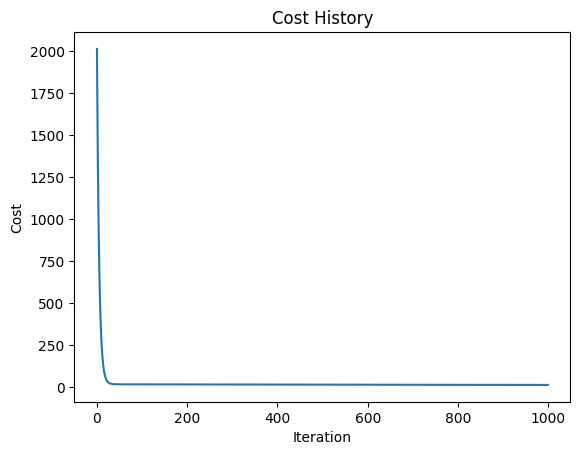

In [29]:
# To-Do 10
def main(alpha=0.00001, iterations=1000):
    # Step 1: Load dataset
    data = pd.read_csv("/content/drive/MyDrive/student.csv")

    # Step 2: Features and target
    X = data[["Math", "Reading"]].values
    Y = data["Writing"].values

    # Step 3: Train-test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # Step 4: Initialize weights
    W = np.zeros(X_train.shape[1])

    # Step 5: Gradient descent
    W_optimal, cost_history = gradient_descent(X_train, Y_train, W, alpha, iterations)

    # Step 6: Predict on test
    Y_pred = np.dot(X_test, W_optimal)

    # Step 7: Evaluate
    model_rmse = rmse(Y_test, Y_pred)
    model_r2 = r2(Y_test, Y_pred)

    # Step 8: Print results
    print("Final Weights:", W_optimal)
    print("Cost History (First 10 iterations):", cost_history[:10])
    print("RMSE on Test Set:", model_rmse)
    print("R-Squared on Test Set:", model_r2)

    # Extra: Plot cost curve
    plt.figure()
    plt.plot(cost_history)
    plt.title("Cost History")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()

    return W_optimal, cost_history, model_rmse, model_r2

# Run
W_optimal, cost_history, model_rmse, model_r2 = main(alpha=0.00001, iterations=1000)


To - Do - 11 - Present your finding:
1. Did your Model Overfitt, Underfitts, or performance is acceptable.
2. Experiment with different value of learning rate, making it higher and lower, observe the result.

In [31]:
# To-Do 11 (Part 1): Check overfitting/underfitting using train vs test error

def evaluate_train_vs_test(alpha, iterations):
    data = pd.read_csv("/content/drive/MyDrive/student.csv")
    X = data[["Math", "Reading"]].values
    Y = data["Writing"].values

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    W = np.zeros(X_train.shape[1])
    W_opt, _ = gradient_descent(X_train, Y_train, W, alpha, iterations)

    # predictions
    Y_train_pred = np.dot(X_train, W_opt)
    Y_test_pred = np.dot(X_test, W_opt)

    train_rmse = rmse(Y_train, Y_train_pred)
    test_rmse = rmse(Y_test, Y_test_pred)

    train_r2 = r2(Y_train, Y_train_pred)
    test_r2 = r2(Y_test, Y_test_pred)

    return train_rmse, test_rmse, train_r2, test_r2

train_rmse, test_rmse, train_r2, test_r2 = evaluate_train_vs_test(alpha=0.00001, iterations=1000)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

if train_rmse < test_rmse * 0.7:
    print("\nConclusion: Likely Overfitting (train error much lower than test).")
elif train_rmse > test_rmse * 1.1:
    print("\nConclusion: Possibly Underfitting (train error not improving well).")
else:
    print("\nConclusion: Performance looks acceptable (train and test are close).")


Train RMSE: 5.128473455543202
Test RMSE: 5.2798239764188635
Train R2: 0.8843826546696121
Test R2: 0.8886354462786421

Conclusion: Performance looks acceptable (train and test are close).


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-841113867.py:11: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum((Y_pred - Y) ** 2)
/tmp/ipython-input-4084282593.py:24: RuntimeWarning: invalid value encountered in subtract
  W_update = W_update - alpha * dw


,alpha,train_rmse,test_rmse,train_r2,test_r2
0,0.000001,5.660001,5.771216,0.859175,0.866941
1,0.000010,4.791962,4.982550,0.899058,0.900823
2,0.000100,4.529799,4.794468,0.909800,0.908169
3,0.001000,NaN,NaN,NaN,NaN


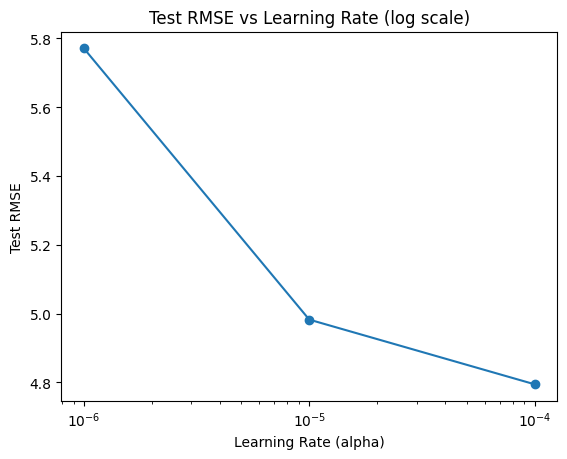

In [32]:
# To-Do 11 (Part 2): Learning rate experiments

alphas = [0.000001, 0.00001, 0.0001, 0.001]
iterations = 2000

results = []

for a in alphas:
    tr_rmse, te_rmse, tr_r2, te_r2 = evaluate_train_vs_test(alpha=a, iterations=iterations)
    results.append((a, tr_rmse, te_rmse, tr_r2, te_r2))

results_df = pd.DataFrame(results, columns=["alpha", "train_rmse", "test_rmse", "train_r2", "test_r2"])
display(results_df)

plt.figure()
plt.plot(results_df["alpha"], results_df["test_rmse"], marker="o")
plt.xscale("log")
plt.title("Test RMSE vs Learning Rate (log scale)")
plt.xlabel("Learning Rate (alpha)")
plt.ylabel("Test RMSE")
plt.show()
